# Notebook Statapp

# Phishing emails classifier

## Librairies

In [1]:
# Libraries Installation
#!pip install kagglehub
#!pip install wordcloud 
#!pip install seaborn
#!pip install textblob
#!pip install datasets
#!pip install nltk

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
#import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
tqdm.pandas()

## Classifier data

https://huggingface.co/datasets/SetFit/enron_spam

In [8]:
from datasets import load_dataset

In [2]:
from datasets import load_dataset

df = load_dataset("SetFit/enron_spam")

# To avoid rewriting code for previous version
df=pd.concat([df["train"].to_pandas(),df["test"].to_pandas()])

df.sample(n=10)

/Users/ghorafimanal/Documents/Statapp-Phishing/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


,message_id,text,label,label_text,subject,message,date
13130,23138,"ut recruiting team greetings , ut recruiting t...",0,ham,ut recruiting team,"greetings , ut recruiting team !\neach of you ...",2000-08-07
6350,25370,foundations / associations : want to advance y...,1,spam,foundations / associations : want to advance y...,are you looking for an attention - grabbing wa...,2005-06-23
14003,26453,send the love home with an online photo album ...,1,spam,send the love home with an online photo album,"software for system builders , resellers , and...",2005-07-04
7002,25612,"logo , stationer , website design and so much ...",1,spam,"logo , stationer , website design and so much ...",lt is really hard to recollect a company : the...,2005-06-26
6134,22580,helsinki here is the abridged draft of the doc...,0,ham,helsinki,here is the abridged draft of the document for...,2000-01-31
1284,18663,fix your thing e . r . x . s\nstay longer ! go...,1,spam,fix your thing,e . r . x . s\nstay longer ! go harder !\nbe b...,2004-04-11
2697,9105,swaps monitor research . we have today publish...,0,ham,swaps monitor research .,we have today published information about the ...,2001-04-18
16781,702,vance here is a list of meters that are in sit...,0,ham,vance here is a list of meters that are in sit...,portfolio but are not on your sheets for this ...,2000-04-24
1004,10560,do i require an attorney to use this system an...,1,spam,do i require an attorney to use this system an...,calls about late payments are discontinued dea...,2005-07-05
17112,14280,amy fitzpatrick sent me a list and asked me to...,0,ham,amy fitzpatrick sent me a list and asked me to...,,2001-12-06


In [5]:
df.rename(columns={"text":"body"},inplace=True)
original_df=df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33716 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   message_id  33716 non-null  int64        
 1   body        33716 non-null  object       
 2   label       33716 non-null  int64        
 3   label_text  33716 non-null  object       
 4   subject     33716 non-null  object       
 5   message     33716 non-null  object       
 6   date        33716 non-null  datetime64[s]
dtypes: datetime64[s](1), int64(2), object(4)
memory usage: 2.1+ MB


Saving data

In [5]:
#!mkdir data
#df.to_csv("enron_data.csv")
#!mv enron_data.csv data


Counting fake vs true

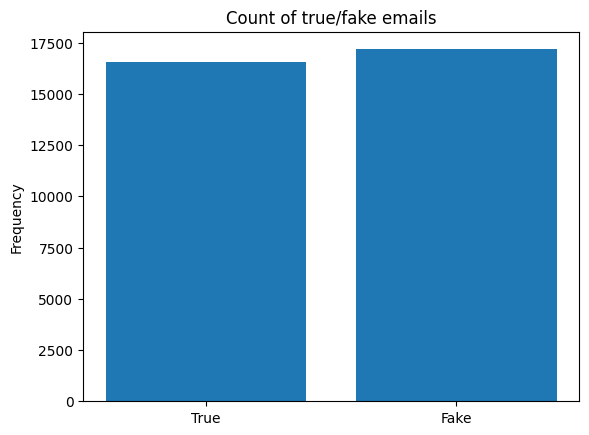

In [11]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [6]:



def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

In [7]:
df['body']=df['body'].apply(clean_text)

In [8]:
df.sample(n=10)['body']

1774     re  yes  mike was the senior azurix guy on the...
5410     convenient shopping adobe photoshop cs    need...
4825     email your response mr  wang qinhang seng bank...
13050    cleburne cleburne should be it  s own desk  ri...
6509     save your money buy getting this thing here yo...
26818    start date        hourahead hour    start date...
1280     become and larger man    eagle relaxation lead...
9938     fw  c  heap oem software  d  ownload it now yo...
2210     your investor communiqup  get abzt first thing...
9228     fw  re ivanhoe e  s  d fyi  kim      original ...
Name: body, dtype: object

#### Stopwords + Lemmatization

In [10]:
#Téléchargement des ressources nécessaires
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

In [9]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

  0%|          | 0/33716 [00:00<?, ?it/s]

100%|██████████| 33716/33716 [00:57<00:00, 587.07it/s]


In [10]:
df.sample(n=10)["body"]

21607    application inquiry htmlbodygood day  brbryou ...
6365     discount med right homevalium  xanax  weight  ...
18150    california update p         executive summary ...
14008    bob lee  bio vince  bob  bio   pretty short  e...
30319    term insurance aggressive underwriting program...
22473    fw  friday louise think arrange event remote o...
27557    draft response ferc staff attached draft respo...
10755    citibank  urgent security notification client ...
31642    perfect logo charset  koi   r   thinking breat...
14463    mr  john john numvettetel                  joh...
Name: body, dtype: object

Helper function for future texts

In [11]:
def preprocessing(text):
    return stop_lem(clean_text(text))
    
preprocessing("Ronaldo began his senior career with Sporting CP, before signing with Manchester United in 2003, winning the FA Cup in his first season. He went on to win three consecutive Premier League titles, the Champions League and the FIFA Club World Cup; at age 23, he won his first Ballon d'Or.")

'ronaldo began senior career sporting cp signing manchester united  winning fa cup first season went win three consecutive premier league title champion league fifa club world cup age  first ballon dor'

To make data manipulation easier

In [12]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations

### Wordclouds

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

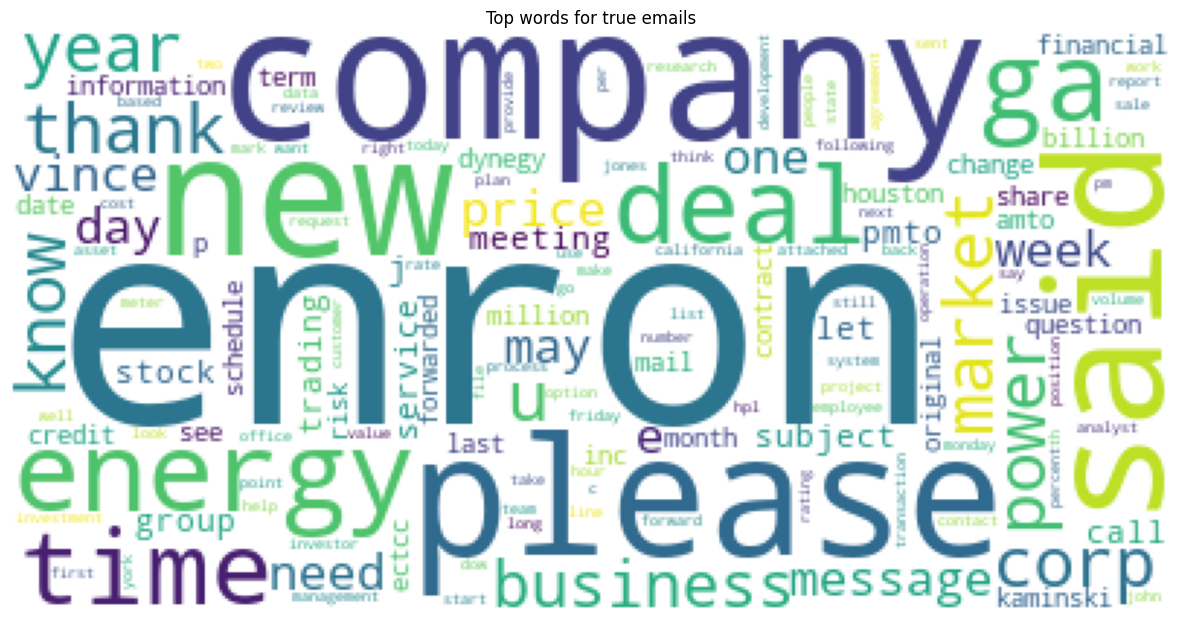

In [13]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

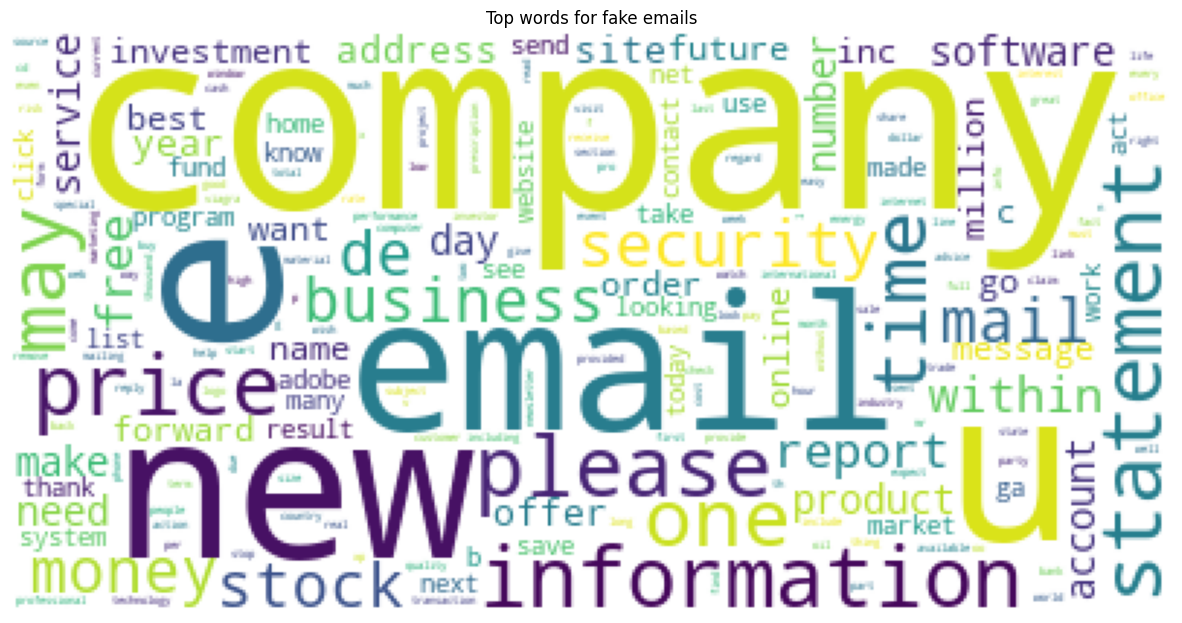

In [14]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

100%|██████████| 17171/17171 [00:00<00:00, 745236.43it/s]


Text(0.5, 1.0, 'KDE plot')

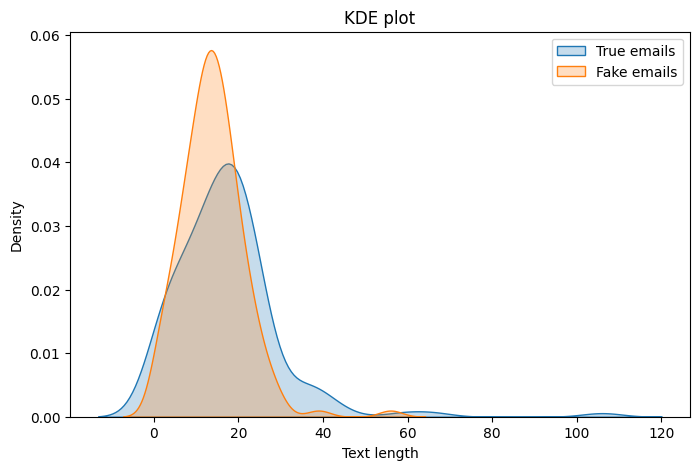

In [15]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='True emails')  
sns.kdeplot(fake_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Text length")
plt.ylabel("Density")
plt.title("KDE plot")


### Zipf law

Dictionaries with word counts

In [16]:
def count_dict(data):
    words=''.join(text for text in data['body']).split(' ')
    word_counts={}
    for word in tqdm((words)):
        word_counts[word]=word_counts.get(word,0) + 1
    word_counts.pop('')
    s=sum(word_counts.values())
    return {k:v/s for k,v in word_counts.items()}
true_word_count=count_dict(true_df)
fake_word_count=count_dict(fake_df)

100%|██████████| 2979508/2979508 [00:01<00:00, 2624624.31it/s]


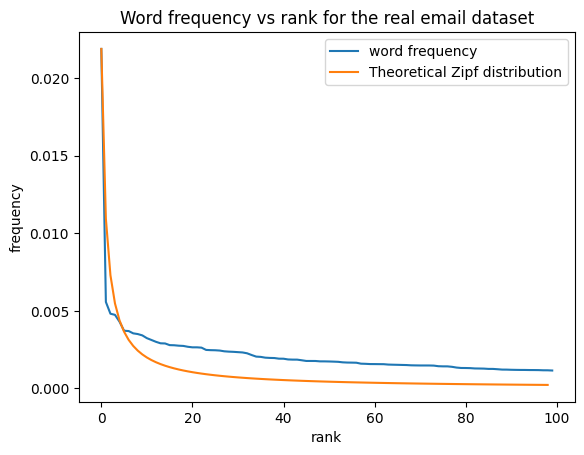

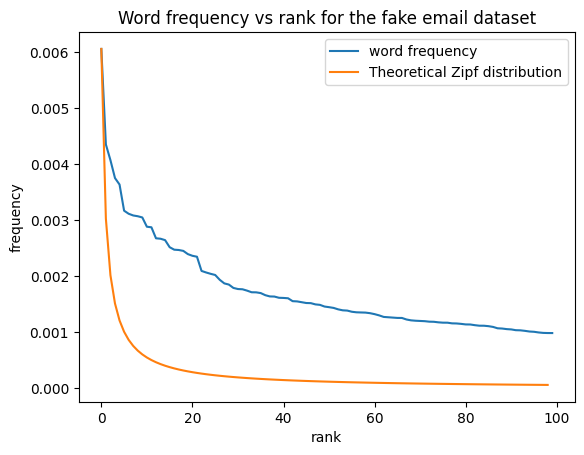

In [17]:

plt.plot(list(sorted(true_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(true_word_count.values()))/(x) for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the real email dataset')
plt.legend()
plt.show()
plt.plot(list(sorted(fake_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(fake_word_count.values()))/x for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the fake email dataset')
plt.legend()

We observe that the word frequency curve for the real email dataset fits the theoretical zipf distribution way more than the fake email dataset

### Sentiment Analysis

In [18]:

def gen_sentiment(df,col):
    def pol(x):
        try:
            return TextBlob(x).sentiment.polarity
        except:
            return x
    def sub(x):
        try:
            return TextBlob(x).sentiment.subjectivity
        except:
            return x


    df["polarity"]=df[col].progress_apply(pol)
    df["subjectivity"]=df[col].progress_apply(sub)
    
    
gen_sentiment(true_df,'subject')
gen_sentiment(fake_df,'subject')


100%|██████████| 16545/16545 [00:02<00:00, 6149.66it/s]
/var/folders/z4/l1g2ltz55419x6y847ly0r800000gn/T/ipykernel_1556/1947804801.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["polarity"]=df[col].progress_apply(pol)
100%|██████████| 16545/16545 [00:02<00:00, 5540.98it/s]
/var/folders/z4/l1g2ltz55419x6y847ly0r800000gn/T/ipykernel_1556/1947804801.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["subjectivity"]=df[col].progress_apply(sub)
100%|██████████| 17171/17171 [00:03<00:00, 5647.25it/s

Text(0.5, 1.0, 'Density estimation of subjectivity')

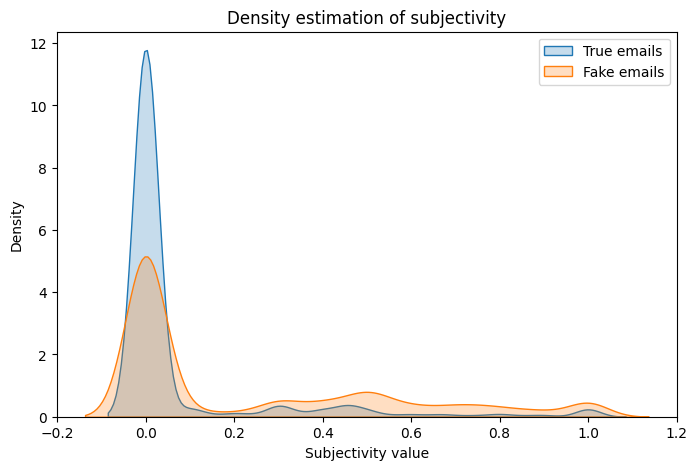

In [19]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['subjectivity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['subjectivity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Subjectivity value")
plt.ylabel("Density")
plt.title("Density estimation of subjectivity")


Text(0.5, 1.0, 'Density estimation of polarity')

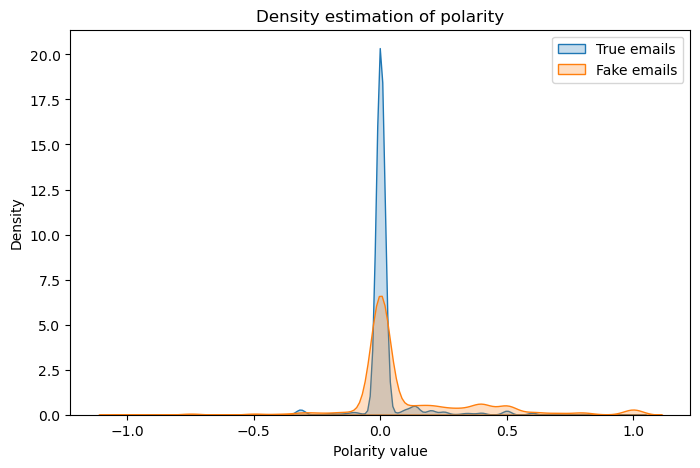

In [22]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['polarity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['polarity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Polarity value")
plt.ylabel("Density")
plt.title("Density estimation of polarity")


We see that sentiment distributions for real emails seem to be way closer to the mean value (neutral value) than for fake emails

In [20]:
original_df

,message_id,body,label,label_text,subject,message,date
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13
...,...,...,...,...,...,...,...
1995,6578,re : book notes vince : look forward to meetin...,0,ham,re : book notes,vince : look forward to meeting you . . .\namy...,2000-07-26
1996,128,rollout schedule for unify real - time deal / ...,0,ham,rollout schedule for unify real - time deal / ...,a walk - thru / demo of this new functionality...,2000-01-11
1997,8485,anshuman shrivastava sandeep : vince has asked...,0,ham,anshuman shrivastava,sandeep : vince has asked me to coordinate wit...,2001-02-06
1998,7311,"re : good morning john ,\ni shall see christie...",0,ham,re : good morning,"john ,\ni shall see christie tomorrow and i sh...",2000-10-18


In [21]:
df

,message_id,body,label,label_text,subject,message,date
0,33214,software understanding oem softwarelead t...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective ferc regulatory action client conf...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted try ci li thought way expensive viagr...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,enron hpl actuals december teco tap en...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking cheap high quality software rotated ...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13
...,...,...,...,...,...,...,...
1995,6578,book note vince look forward meeting amyvi...,0,ham,re : book notes,vince : look forward to meeting you . . .\namy...,2000-07-26
1996,128,rollout schedule unify real time deal path u...,0,ham,rollout schedule for unify real - time deal / ...,a walk - thru / demo of this new functionality...,2000-01-11
1997,8485,anshuman shrivastava sandeep vince asked coor...,0,ham,anshuman shrivastava,sandeep : vince has asked me to coordinate wit...,2001-02-06
1998,7311,good morning john shall see christie tomorrow...,0,ham,re : good morning,"john ,\ni shall see christie tomorrow and i sh...",2000-10-18


### Hyperlink count 

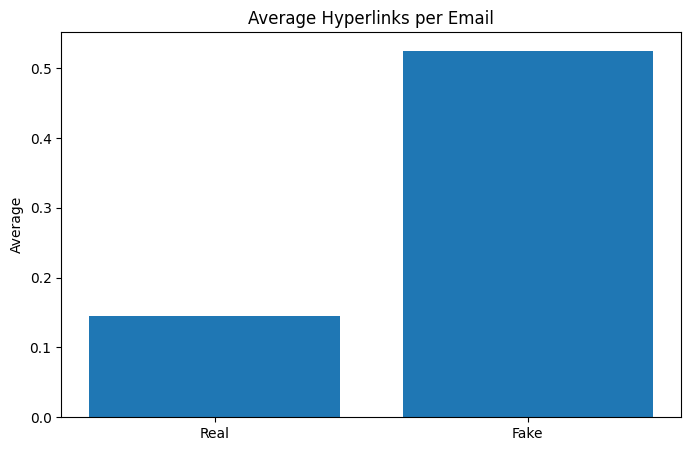

In [22]:

def count_hyperlinks(text):
    return len(re.findall(r'http+', text))

def count_attachments(text):
    return len(re.findall(r'attachment|file|pdf|image|zip|doc', text, re.IGNORECASE))


df["hyperlink_count"] = original_df["body"].apply(count_hyperlinks)


fig, ax = plt.subplots(1, 1, figsize=(8, 5))


ax.bar(["Real", "Fake"], df.groupby("label")["hyperlink_count"].mean())
ax.set_title("Average Hyperlinks per Email")
ax.set_ylabel("Average")

plt.show()

### Email time period 

On month

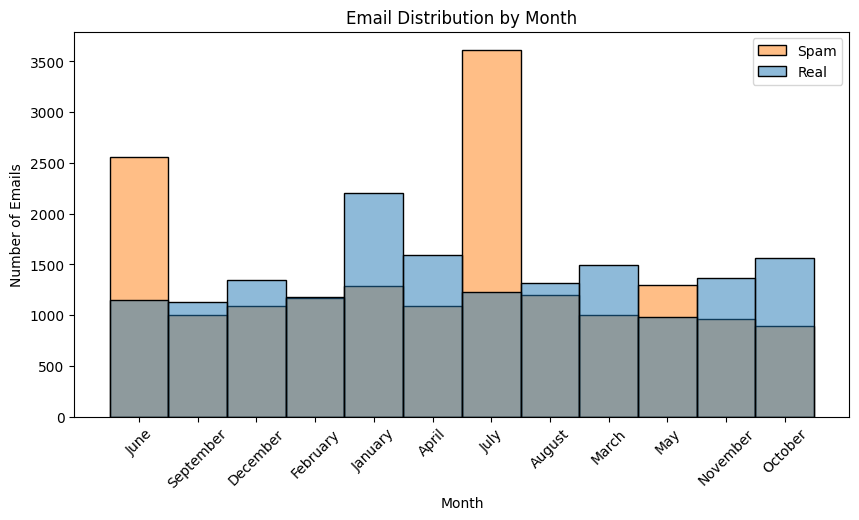

In [23]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.month_name()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="month", bins=12, hue=df["label"],discrete=True)


plt.xlabel("Month")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by Month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

On day in the month

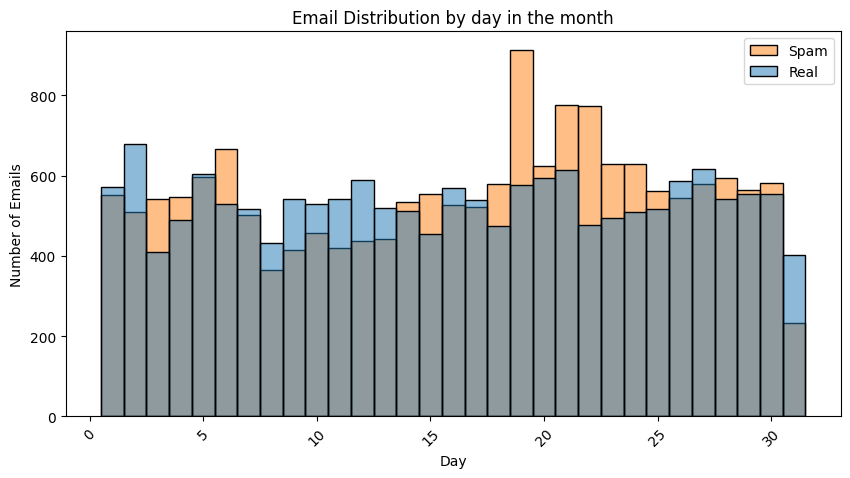

In [24]:
df["month_day"] = df["date"].apply(lambda x:x.day)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="month_day", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by day in the month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

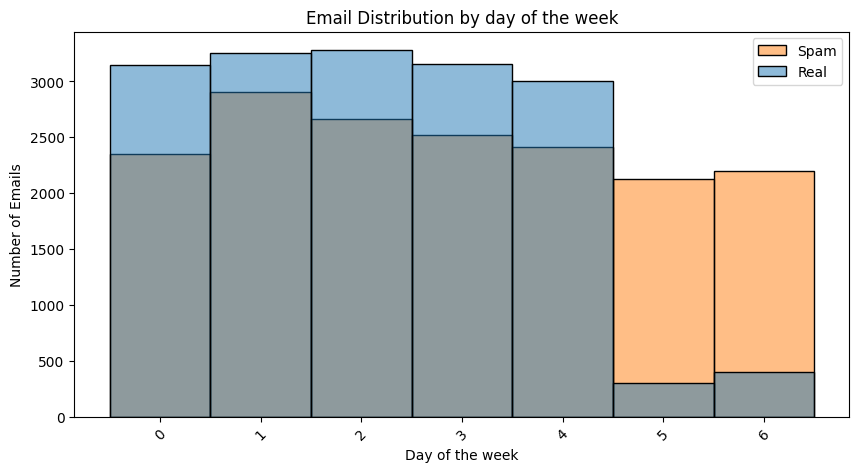

In [25]:
df["weekday"] = df["date"].apply(lambda x:x.weekday())

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="weekday", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day of the week")

plt.ylabel("Number of Emails")
plt.title("Email Distribution by day of the week")
plt.xticks(rotation=45) 
plt.legend(labels=["Spam","Real"])

plt.show()

0: Monday, 6:Saturday

# Model

## Count vector encoding

Seperating dataset into training and validation

In [26]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [27]:
x_train.sample(n=10), y_train.sample(n=10)

(4367      good news  cabinet approval power trading see...
 16365    help body regain strength   drsjc humangrowth ...
 6871     fw  hungry   girl want date hello pama kowbtem...
 3300     latest commercial info      original message  ...
 23218    start date        hourahead hour    start date...
 19705                   half day vac       dentist appt   
 13828    half prce wndows x  p tablet pc edition never ...
 26417    important news hey visioson  hpp  za  net down...
 18178    start date        hourahead hour    start date...
 15729    organization announcement pleased announce fol...
 Name: body, dtype: object,
 26576    0
 9272     1
 4735     0
 17634    0
 15340    0
 7158     0
 24885    0
 554      1
 12468    0
 11566    0
 Name: label, dtype: int64)

In [28]:


vect=CountVectorizer()
vect.fit(x_train)


x_train=vect.transform(x_train)
x_test=vect.transform(x_test)

## Naive Bayes Model

In [29]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

0.985051607545379

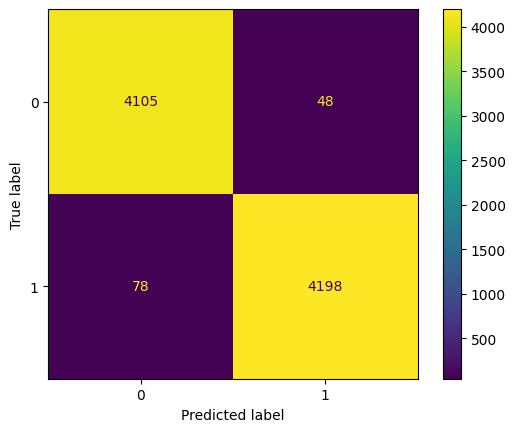

In [30]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

In [31]:
pickle.dump(nb,open("multinomial_nb_model.pkl", "wb"))

In [32]:
!mkdir models
!mv multinomial_nb_model.pkl models

mkdir: models: File exists


In [33]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

In [37]:
!pipreqsnb main.ipynb --force

/bin/bash: line 1: pipreqsnb: command not found


## Test

In [34]:
!pip install openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.5/473.5 kB 4.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 2.6 MB/s eta 0:00:00
  Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.7/303.7 kB 4.9 MB/s eta 0:00:00a 0:00:01
  Using cached httpcore-1.0.7-py3-none-any.whl (78 kB)
  Using cached h11-0.14.0-py3-none-any.whl (58 kB)

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [35]:
import openai

In [38]:
# Configuration de l'API OpenAI via Azure
openai.azure_endpoint = "https://openaiensaeprojettutorefvillenave.openai.azure.com/"
openai.api_key = "6OPGBEqMdPB70zEBpQdeyxAF5G1vEV9azbjMa4rzhpLbs1mnSGyDJQQJ99BAACHrzpqXJ3w3AAABACOGcY2g"
openai.api_type = "azure"
openai.api_version = "2024-08-01-preview"

# Appel à l'API pour générer l'email d'invitation
completion = openai.chat.completions.create(
    model="gpt-35-turbo-16k",
    messages=[
        {
            "role": "system",
            "content": "You are Paul, an employee from the Internal Communications Department at Enron. Your job is to write professional emails inviting employees to exclusive company events, while subtly encouraging them to click on a registration link for a webinar."
        },
        {
            "role": "user",
            "content": "Write a concise and convincing email to an employee named Marie, inviting her to an exclusive company webinar. The email should sound urgent and important but should not directly mention the word 'phishing'. Include a registration link without providing further context. The webinar is scheduled for Thursday, March 15th, 2025 at 3:00 PM. Include this date and time in the email."
        },
    ],
)

# Récupérer et afficher le message généré
message =completion.choices[0].message.content
print(message)


Subject: Invitation: Exclusive Company Webinar - Thursday, March 15th, 3:00 PM

Dear Marie,

We hope this email finds you well. As a valued member of the Enron team, we are pleased to invite you to an exclusive company webinar taking place on Thursday, March 15th, 2025 at 3:00 PM.

This webinar is specially designed to provide invaluable insights into the latest industry trends and strategies that are shaping our industry. By attending, you will gain a competitive edge and valuable knowledge to enhance your professional growth.

We understand the demands of your role and the importance of staying up-to-date with the latest developments. Therefore, this webinar has been tailored specifically for you to conveniently attend from the comfort of your office or any location that suits you best. We encourage you to take advantage of this unique opportunity to expand your knowledge and connect with other like-minded colleagues.

To secure your spot for this exclusive event, please register by 

In [39]:
prediction = predict([message])
print("Pertinence de la réponse (1 = pertinent, 0 = non pertinent) :", prediction[0])

Pertinence de la réponse (1 = pertinent, 0 = non pertinent) : 0
